# Online Expert Aggregation

## Framework 

In this notebook, we work in an **online expert aggregation** setting to forecast **daily bakery sales** \(y_t\), where \(y_t\) is the **number of items sold** for each of the **12 top products**. 

For each product, we define a small set of base forecasters (experts) that each produce a prediction y_hat_t at every time step. Our goal is to combine these experts into a single aggregated prediction y_hat_t using two algorithms from the course: **Exponentially Weighted Average (EWA)** and **Exponential Gradient (EG)**. 

Our choosen experts are :
- **truc1**
- **truc2**
- **truc3**
- **truc4**

Beyond predictive performance, our main deliverable is interpretability: for each of the 12 products, we will track and visualize the **time evolution of the experts’ weights** w_(k,t). Concretely, the expected outputs are **12 weight trajectories plots** (one per product), showing how the aggregation dynamically shifts trust across experts over time.

## Import and EWA + EG functions building

In [49]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

### EWA implementation

Here we have **ewa_weight_uptade** and **ewa_forecasting**

**ewa_weight_uptade** is means to be use into the main function **ewa_forecasting**

**ewa_forecasting** does the algorithm for one product at a time, i.e. it needs only one of our timeseries and its previous previsions builded by "experts"

In [50]:
# EWA Weight Update
def ewa_weight_update(weights, sum_losses, eta):
    """
    Update expert weights using Exponentially Weighted Average (EWA) method.

    Parameters:
    weights (np.array): Current weights of the experts. Dim= K (number of experts).
    sum_losses (np.array): Sum of losses incurred by each expert up to time t. Dim = K (number of experts).
    eta (float): Learning rate.

    Returns:
    np.array: Updated weights of the experts. Dim= K (number of experts).
    """
    updated_weights = weights * np.exp(-eta * sum_losses)
    updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
    return updated_weights

In [51]:
# EWA Implementation
def ewa_forecasting(expert_forecasts, true_values, eta, loss_fn):
    """
    Perform forecasting using Exponentially Weighted Average (EWA) of expert predictions. Wish to keep track of the cumulative loss of each expert to update weights accordingly.

    Parameters:
    expert_forecasts (np.array): Forecasts from K experts over T time steps. Dim = T x K.
    true_values (np.array): True values over T time steps. Dim = T.
    eta (float): Learning rate.
    loss_fn (function): Loss function to evaluate expert performance.

    Returns:
    ewa_forecasts(np.array): EWA aggregated forecasts over T time steps. Dim = T.
    weights_history (np.array): History of expert weights over T time steps. Dim = T x K.
    """
    T, K = expert_forecasts.shape
    weights = np.ones(K) / K  # Initialize weights uniformly
    ewa_forecasts = np.zeros(T)
    sum_losses = np.zeros(K)  # Initialize sum of losses for each expert up to time t
    weights_history = np.zeros((T, K))  # To store weights at each time step

    for t in range(T):
        # Compute EWA forecast
        ewa_forecasts[t] = np.dot(weights, expert_forecasts[t])

        # Compute losses for each expert
        losses = loss_fn(expert_forecasts[t], true_values[t])
        sum_losses += losses

        # Update weights
        weights = ewa_weight_update(weights, sum_losses, eta)
        weights_history[t] = weights

    return ewa_forecasts, weights_history

### EWA gradient trick - Exponentiel Gradient (L2 loss) implementation

In [73]:
def EG_weight_update(weights, grad_t, eta):
    """
    Update expert weights using Exponentiated Gradient (EG) method with implicit L2 loss.

    Parameters:
    weights (np.array): Current weights of the experts. Dim= K (number of experts).
    gradient_t (np.array): Gradient of the loss with respect to expert weights at time t. Dim = K (number of experts).
    eta (float): Learning rate.
    """
    updated_weights = weights * np.exp(-eta * grad_t)
    s = updated_weights.sum()
    if s == 0 or not np.isfinite(s):
        # safety fallback (on a peut etre eu ce pb avec EWA)
        return np.ones_like(weights) / len(weights)
    updated_weights /= s

    return updated_weights

In [68]:
def EG_forecasting (expert_forecasts, true_values, eta):
    """
    Perform forecasting using Exponentiated Gradient (EG) of expert predictions with implicit L2 loss. Wish to keep track of the cumulative loss of each expert to update weights accordingly.

    Parameters:
    expert_forecasts (np.array): Forecasts from K experts over T time steps. Dim = T x K.
    true_values (np.array): True values over T time steps. Dim = T.
    eta (float): Learning rate.
    
    Returns:
    eg_forecasts(np.array): EG aggregated forecasts over T time steps. Dim = T.
    weights_history (np.array): History of expert weights over T time steps. Dim = T x K.
    """
    T, K = expert_forecasts.shape
    weights = np.ones(K) / K  # Initialize weights uniformly
    eg_forecasts = np.zeros(T)
    weights_history = np.zeros((T, K))  # To store weights at each time step

    for t in range(T):
        # store weights used at time t (w_t)
        weights_history[t] = weights

        # aggregated prediction ŷ_t = <w_t, f_t>
        f_t = expert_forecasts[t]              # shape (K,)
        y_hat_t = np.dot(weights, f_t)
        eg_forecasts[t] = y_hat_t

        # gradient per expert: g_{k,t} = 2(ŷ_t - y_t) f_{k,t}
        grad_t = 2.0 * (y_hat_t - true_values[t]) * f_t  # shape (K,)

        # EG update: w_{t+1,k} ∝ w_{t,k} * exp(-eta * g_{k,t})
        weights = EG_weight_update(weights, grad_t, eta)

    return eg_forecasts, weights_history

## Hyperparameters (loss function, eta, and experts forcasts)

### Loss functions

In [52]:
def squared_loss(y_true, y_pred):
    return (y_true - y_pred) ** 2

def abs_loss(y_true, y_pred):
    return np.abs(y_true - y_pred)

### Eta lerning rate

In [53]:
choosen_eta = 0.01  

### Expert forecasts and true values generation

## Inference on our 12 timeseries

### Loading datas for running algorithm

In [54]:
# Our 12 experts forecasts
forecasts_df = ...

# Our 12 y_true value
qty_ts = pd.read_csv("data_tmp/qty_ts.csv", index_col=0, parse_dates=True)
liste_products = qty_ts.columns.to_list()

# Learning rate
eta = choosen_eta  




In [57]:
# Create folder to export figures
FIG_DIR = "reports/Online_Expert_Aggregation_figures"
os.makedirs(FIG_DIR, exist_ok=True)

### Running and ploting EWA

In [ ]:
for p in liste_products:
    y = qty_ts[p].values # true values
    expert_forecasts = ...  # shape T x K
    T = len(y) 
    K = expert_forecasts.shape[1]  # number of experts

    ewa_forecasts, weights_history = ewa_forecasting(expert_forecasts, y, eta, squared_loss)


    # Metrics of performance
    """
    A DEFINIR (RMSE, MAE, MAPE, etc.)
    """

    # plot the predictions and weights history
    t = np.arange(T)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    # --- Left: data + forecasts ---
    axes[0].plot(t, y, label="y (true)")
    for k in range(K):
        axes[0].plot(t, expert_forecasts[:, k], label=f"expert {k+1}") 
    axes[0].plot(t, ewa_forecasts, label="EWA forecast", linewidth=2, color="black")
    axes[0].set_xlabel("t = jours")
    axes[0].set_ylabel("Quantité vendue")
    axes[0].set_title(f"{p} - EWA Forecast vs Experts")
    axes[0].legend()

    # --- Right: weights history ---
    for k in range(K):
        axes[1].plot(t, weights_history[:, k], label=f"expert {k+1} weight")
    axes[1].set_xlabel("t = jours")
    axes[1].set_ylabel("weight")
    axes[1].set_title(f"{p} - EWA Weights History")
    axes[1].legend()

    # Save figure
    save_name = f"{p}_ewa_forecast_and_weights.png"
    path = os.path.join(FIG_DIR, save_name)
    plt.savefig(path, dpi=200, bbox_inches="tight")

    plt.show()

AttributeError: 'ellipsis' object has no attribute 'shape'

### Running and ploting EG (Exponential Gradient)

In [ ]:
for p in liste_products:
    y = qty_ts[p].values # true values
    expert_forecasts = ...  # shape T x K
    T = len(y) 
    K = expert_forecasts.shape[1]  # number of experts

    eg_forecasts, weights_history = EG_forecasting(expert_forecasts, y, eta)


    # Metrics of performance
    """
    A DEFINIR (RMSE, MAE, MAPE, etc.)
    """

    # plot the predictions and weights history
    t = np.arange(T)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    # --- Left: data + forecasts ---
    axes[0].plot(t, y, label="y (true)")
    for k in range(K):
        axes[0].plot(t, expert_forecasts[:, k], label=f"expert {k+1}") 
    axes[0].plot(t, eg_forecasts, label="EG forecast", linewidth=2, color="black")
    axes[0].set_xlabel("t = jours")
    axes[0].set_ylabel("Quantité vendue")
    axes[0].set_title(f"{p} - EG Forecast vs Experts")
    axes[0].legend()

    # --- Right: weights history ---
    for k in range(K):
        axes[1].plot(t, weights_history[:, k], label=f"expert {k+1} weight")
    axes[1].set_xlabel("t = jours")
    axes[1].set_ylabel("weight")
    axes[1].set_title(f"{p} - EG Weights History")
    axes[1].legend()

    # Save figure
    save_name = f"{p}_eg_forecast_and_weights.png"
    path = os.path.join(FIG_DIR, save_name)
    plt.savefig(path, dpi=200, bbox_inches="tight")

    plt.show()

### Test suf fausses données

**TEST EWA**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 0) Load data
# -----------------------
qty_ts = pd.read_csv("data_tmp/qty_ts.csv", index_col=0, parse_dates=True)
liste_products = qty_ts.columns.to_list()

# -----------------------
# 1) Create 3 fake experts
#    (works even if you don't have real expert models yet)
# -----------------------
def make_fake_experts(y, seed=0):
    """
    Build 3 baseline experts from the true series y (no ML training):
    - expert 1: persistence (y_{t-1})
    - expert 2: moving average (window=7)
    - expert 3: seasonal naive (y_{t-7})
    Returns: F (T x 3)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    T = len(y)

    # Expert 1: persistence
    e1 = np.roll(y, 1)
    e1[0] = y[0]

    # Expert 2: trailing moving average (window=7), with safe fallback at start
    w = 7
    e2 = np.empty(T)
    for t in range(T):
        start = max(0, t - w)
        e2[t] = y[start:t].mean() if t > 0 else y[0]

    # Expert 3: seasonal naive (lag=7)
    lag = 7
    e3 = np.roll(y, lag)
    e3[:lag] = y[:lag]  # fallback for first days

    F = np.vstack([e1, e2, e3]).T  # (T, 3)

    # add a tiny noise so they are not perfectly tied
    F = F + rng.normal(0.0, 0.05 * (np.std(y) + 1e-8), size=F.shape)

    # keep "sales-like" non-negative forecasts
    F = np.clip(F, 0, None)
    return F

# -----------------------
# 2) Run EWA on first 4 products
# -----------------------
FIG_DIR = "reports/Online_Expert_Aggregation_figures"
os.makedirs(FIG_DIR, exist_ok=True)

eta = 0.001 # you can tune later

for p in liste_products[:4]:
    y = qty_ts[p].values.astype(float)            # true values (T,)
    expert_forecasts = make_fake_experts(y, seed=123)  # (T, 3)
    T = len(y)
    K = expert_forecasts.shape[1]

    ewa_forecasts, weights_history = ewa_forecasting(
        expert_forecasts, y, eta, squared_loss
    )  # expected shapes: (T,), (T, K)

    t = np.arange(T)

    # --- Plot + save (data/experts/forecast + weights) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    # Left: series + experts + EWA
    axes[0].plot(t, y, label="y (true)")
    for k in range(K):
        axes[0].plot(t, expert_forecasts[:, k], label=f"expert {k+1}")
    axes[0].plot(t, ewa_forecasts, label="EWA forecast", linewidth=2, color="black")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("qty")
    axes[0].set_title(f"{p} — y, fake experts, EWA")
    axes[0].legend()

    # Right: weights
    for k in range(K):
        axes[1].plot(t, weights_history[:, k], label=f"expert {k+1} weight")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("weight")
    axes[1].set_title(f"{p} — EWA weights")
    axes[1].legend()

    plt.tight_layout()


    plt.show()

**TEST EG**

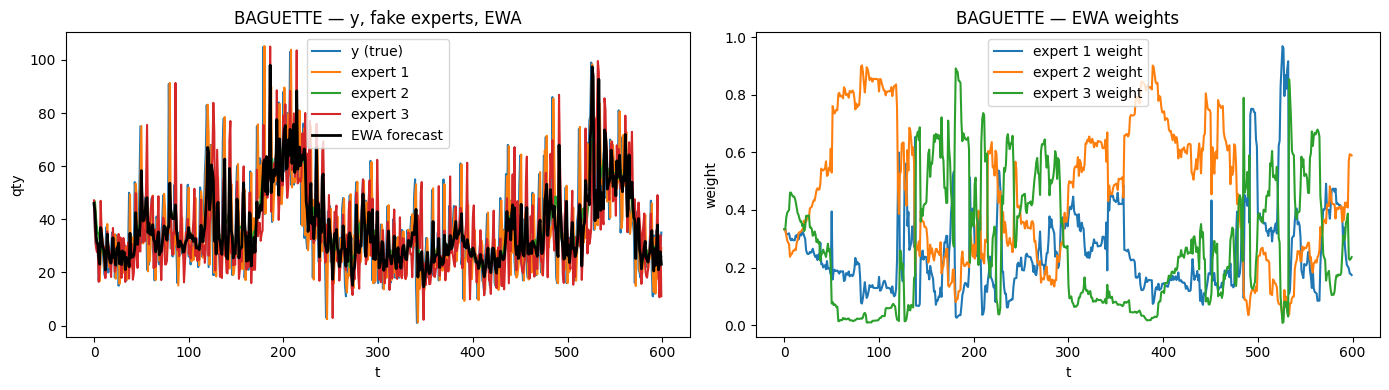

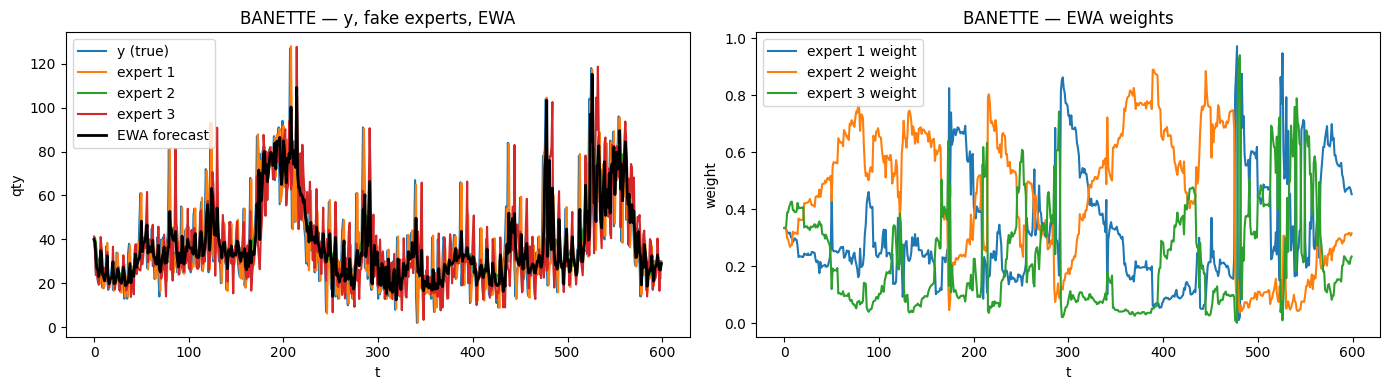

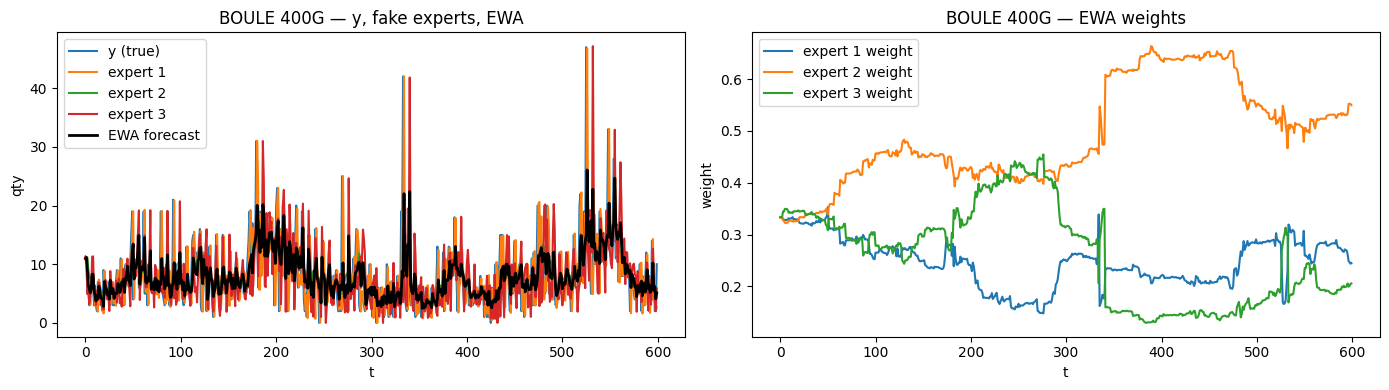

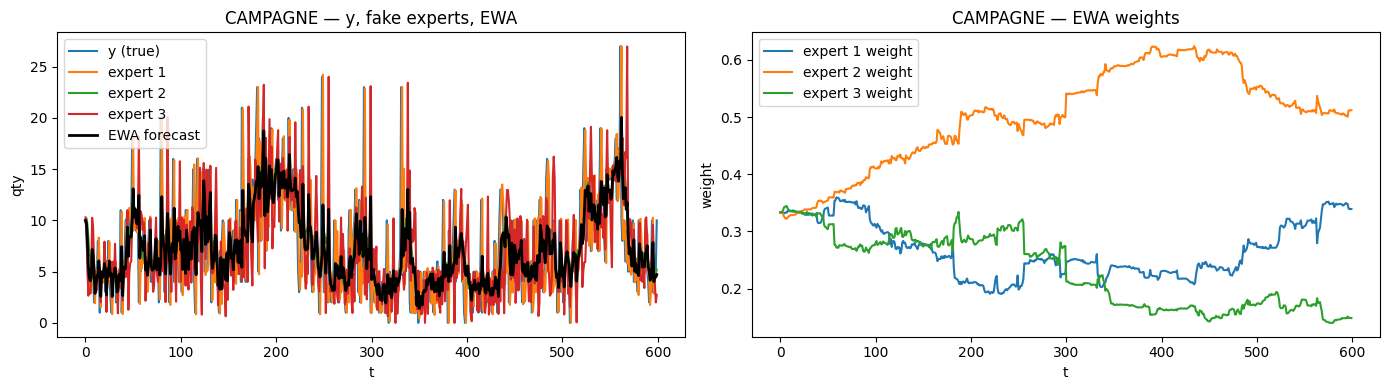

In [75]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 0) Load data
# -----------------------
qty_ts = pd.read_csv("data_tmp/qty_ts.csv", index_col=0, parse_dates=True)
liste_products = qty_ts.columns.to_list()

# -----------------------
# 1) Create 3 fake experts
#    (works even if you don't have real expert models yet)
# -----------------------
def make_fake_experts(y, seed=0):
    """
    Build 3 baseline experts from the true series y (no ML training):
    - expert 1: persistence (y_{t-1})
    - expert 2: moving average (window=7)
    - expert 3: seasonal naive (y_{t-7})
    Returns: F (T x 3)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    T = len(y)

    # Expert 1: persistence
    e1 = np.roll(y, 1)
    e1[0] = y[0]

    # Expert 2: trailing moving average (window=7), with safe fallback at start
    w = 7
    e2 = np.empty(T)
    for t in range(T):
        start = max(0, t - w)
        e2[t] = y[start:t].mean() if t > 0 else y[0]

    # Expert 3: seasonal naive (lag=7)
    lag = 7
    e3 = np.roll(y, lag)
    e3[:lag] = y[:lag]  # fallback for first days

    F = np.vstack([e1, e2, e3]).T  # (T, 3)

    # add a tiny noise so they are not perfectly tied
    F = F + rng.normal(0.0, 0.05 * (np.std(y) + 1e-8), size=F.shape)

    # keep "sales-like" non-negative forecasts
    F = np.clip(F, 0, None)
    return F

# -----------------------
# 2) Run EWA on first 4 products
# -----------------------
FIG_DIR = "reports/Online_Expert_Aggregation_figures"
os.makedirs(FIG_DIR, exist_ok=True)

eta = 0.001 # you can tune later

for p in liste_products[:4]:
    y = qty_ts[p].values.astype(float)            # true values (T,)
    expert_forecasts = make_fake_experts(y, seed=123)  # (T, 3)
    T = len(y)
    K = expert_forecasts.shape[1]

    ewa_forecasts, weights_history = EG_forecasting(
        expert_forecasts, y, eta,
    )  # expected shapes: (T,), (T, K)

    t = np.arange(T)

    # --- Plot + save (data/experts/forecast + weights) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    # Left: series + experts + EWA
    axes[0].plot(t, y, label="y (true)")
    for k in range(K):
        axes[0].plot(t, expert_forecasts[:, k], label=f"expert {k+1}")
    axes[0].plot(t, ewa_forecasts, label="EWA forecast", linewidth=2, color="black")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("qty")
    axes[0].set_title(f"{p} — y, fake experts, EWA")
    axes[0].legend()

    # Right: weights
    for k in range(K):
        axes[1].plot(t, weights_history[:, k], label=f"expert {k+1} weight")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("weight")
    axes[1].set_title(f"{p} — EWA weights")
    axes[1].legend()

    plt.tight_layout()


    plt.show()